In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

# 0. Cargar Datos

In [ ]:
# Cargar datos
columnas_segmentacion = ["Año", "Mes", "Cod Cliente", "Cod SKU", "Nombre Consolidado", "Zona"]
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)#, usecols=columnas_segmentacion)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

In [142]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto', 'familia_marca', 'zonal'],
      dtype='str')

In [ ]:
ventas["familia_marca"] = ventas["Nombre Familia"].astype(str) + ventas["Nombre Marca"].astype(str)

In [ ]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[
    (ventas["Cod Canal Comercial"] == "CB") &
    (ventas["Nombre Consolidado"].isin(canales_relevantes))
    ]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

In [ ]:
path_info_zonales = "datos/Clientes - Zonales.xlsx"
zonales = pd.read_excel(path_info_zonales)
zonales.head()

In [ ]:
zonales.columns

In [ ]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

In [ ]:
clientes.columns

In [ ]:
path_segmentacion_prods = "datos/segmentacion_productos.xlsx"
segmentacion_productos = pd.read_excel(path_segmentacion_prods)
nombres_sku = (
    segmentacion_productos[["sku", "descripción"]]
    .drop_duplicates(subset="sku")
    .set_index("sku")["descripción"]
)

# 1. Cruces de bases y filtros

In [ ]:
ventas = ventas.merge(zonales[["Id cliente", "REGIONES"]].rename(columns={"Id cliente": "Cod Cliente", "REGIONES": "zonal"}), on="Cod Cliente", how="left")

In [ ]:
# Filtrar a solo segundo semestre de 2025
ventas = ventas[ventas["Año"] == 2025]
ventas = ventas[ventas["Mes"] >= 7]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

In [ ]:
# Excluir clientes por TipoNeg antes de armar la matriz cliente-SKU
tipos_neg_excluidos = ["MO", "SN", "SR", "CD", "CZ", "DG", "EC", "PC", "HR"]
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes_tiponeg = pd.read_excel(path_clientes, header=1, usecols=["CodCliente", "TipoNeg"])

ventas = ventas.merge(
    clientes_tiponeg.drop_duplicates(subset=["CodCliente"]),
    left_on="Cod Cliente",
    right_on="CodCliente",
    how="left",
)
ventas = ventas.loc[~ventas["TipoNeg"].isin(tipos_neg_excluidos)].drop(columns=["CodCliente", "TipoNeg"])
print("Ventas después de filtrar TipoNeg excluidos - Filas:", ventas.shape[0])
ventas.head()

In [ ]:
ventas = ventas[ventas["Cod Canal Comercial"]=="CB"]
ventas["Cod Canal Comercial"].value_counts()

# 2. Crear segmentación (Funciones)

In [ ]:
parametros_kmeans = {
    "random_state": 42,
    "batch_size": 4096,
    "n_init": "auto",
}

In [176]:
def preparar(
        ventas_df,
        columna_producto,
        conteo_compra,
        verbosity=False
):
    # Armar matriz cliente-SKU
    if not isinstance(ventas_df, pd.DataFrame):
        raise TypeError("ventas_df debe ser un DataFrame de pandas. Reejecuta las celdas de preparación de ventas.")
    cols = ["Cod Cliente", columna_producto]
    columnas_faltantes = [col for col in cols if col not in ventas_df.columns]
    if columnas_faltantes:
        raise KeyError(f"Columnas faltantes en ventas_df: {columnas_faltantes}")
    
    # 1 si compró alguna vez en los últimos 6 meses
    if conteo_compra == "binario":
        compras_cliente_sku = ventas_df[cols].drop_duplicates()
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        ).astype(np.uint8)

    # Conteo de veces que compró en los últimos 6 meses
    elif conteo_compra == "conteo":
        compras_cliente_sku = ventas_df[cols]
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        ).astype(np.uint8)

    # Porcentaje de la cantidad de compras
    elif conteo_compra == "pg_compras":
        compras_cliente_sku = ventas_df[cols]
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        )
        matriz_cliente_sku = matriz_cliente_sku.div(
            matriz_cliente_sku.sum(axis=1),
            axis=0
        ).fillna(0)
        matriz_cliente_sku = matriz_cliente_sku.astype(np.float32)

    # Porcentaje de los ingresos
    elif conteo_compra == "pg_ingresos": 
        compras_cliente_sku = ventas_df[["Cod Cliente", columna_producto, "Monto Real"]].copy()
        matriz_cliente_sku = (
            compras_cliente_sku
            .groupby(["Cod Cliente", columna_producto])["Monto Real"]
            .sum()
            .unstack(fill_value=0)
        )
        matriz_cliente_sku = matriz_cliente_sku.div(
            matriz_cliente_sku.sum(axis=1),
            axis=0
        ).fillna(0)
        matriz_cliente_sku = matriz_cliente_sku.astype(np.float32)

    else:
        raise ValueError(f"conteo_compra no soportado: {conteo_compra}")
    if verbosity:
        print("Matriz cliente-SKU:", matriz_cliente_sku.shape)
        display(matriz_cliente_sku.head())
    
    return matriz_cliente_sku

In [ ]:
def segmentar(
        matriz_cliente_sku,
        k,      # kmeans
        verbosity=False     # Mostrar proceso o no
):
    # Normalizar aproxima clustering por similitud coseno sin construir una matriz cliente-cliente
    X_clientes = csr_matrix(matriz_cliente_sku.to_numpy(dtype=np.float32))
    X_clientes = normalize(X_clientes, norm="l2", copy=False)
    if verbosity:
        print("Matriz sparse normalizada:", X_clientes.shape, "nnz=", X_clientes.nnz)

    modelo_clusters = MiniBatchKMeans(
        n_clusters=k,
        **parametros_kmeans,
    )
    clusters = modelo_clusters.fit_predict(X_clientes) + 1

    segmentacion_clientes = pd.DataFrame({
        "Cod Cliente": matriz_cliente_sku.index,
        "cluster": clusters,
    })
    return segmentacion_clientes

In [ ]:
def obtener_canasta(
        cluster_elegido,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,    # Familia, Familia-marca, Subfamilia, SKU
        umbral=0.5,          # A partir de qué porcentaje de pertenencia considero un producto como miembro de la canasta
        verbosity=False
):
    clientes_cluster = segmentacion_clientes[segmentacion_clientes["cluster"] == cluster_elegido]["Cod Cliente"]
    skus_cluster = matriz_cliente_sku.loc[clientes_cluster]

    tabla_skus_comunes_cluster = (
        skus_cluster.sum()
        .sort_values(ascending=False)
        .rename_axis(granularidad_sku)
        .reset_index(name="conteo_clientes")
    )
    if granularidad_sku == "Cod SKU":
        tabla_skus_comunes_cluster["nombre_sku"] = (
            tabla_skus_comunes_cluster["Cod SKU"].map(nombres_sku).fillna("SKU sin descripcion")
        )
    cantidad_clientes_cluster = len(clientes_cluster)
    tabla_skus_comunes_cluster["porcentaje_clientes_cluster"] = (
        tabla_skus_comunes_cluster["conteo_clientes"] / cantidad_clientes_cluster
    )
    tabla_skus_comunes_cluster = tabla_skus_comunes_cluster[
        [granularidad_sku, "conteo_clientes", "porcentaje_clientes_cluster"]
    ]

    if verbosity:
        display(tabla_skus_comunes_cluster.head(n=20))

    skus_canasta = tabla_skus_comunes_cluster[
        tabla_skus_comunes_cluster["porcentaje_clientes_cluster"] > umbral
    ][granularidad_sku].unique()

    if verbosity:
        print(f"Canasta del cluster: {skus_canasta}")

    return skus_canasta

In [180]:
def evaluar_segmentaciones(
        ventas_df,
        matriz_cliente_sku,
        ks_clustering,
        granularidad_sku,
        conteo_compra,
        umbral=0.5,
        verbosity=False
):
    X_clientes = csr_matrix(matriz_cliente_sku.to_numpy(dtype=np.float32))
    X_clientes = normalize(X_clientes, norm="l2", copy=False)
    if verbosity:
        print("Matriz sparse normalizada:", X_clientes.shape, "nnz=", X_clientes.nnz)

    k_max = X_clientes.shape[0] - 1
    rango_clusters = [k for k in ks_clustering if 2 <= k <= k_max]
    if not rango_clusters:
        raise ValueError(
            f"No hay valores validos en ks_clustering para {X_clientes.shape[0]} clientes. Usa k entre 2 y {k_max}."
        )

    tamano_muestra_silhouette = min(30000, X_clientes.shape[0])
    if verbosity:
        print(f"Calculando silhouette sobre una muestra de {tamano_muestra_silhouette} clientes")

    resultados_segmentacion = []
    for k in rango_clusters:
        # Fiteamos datos a K-Means
        modelo_tmp = MiniBatchKMeans(
            n_clusters=k,
            **parametros_kmeans,
        )
        labels_tmp = modelo_tmp.fit_predict(X_clientes)

        # Evaluamos según silueta
        score_silhouette = silhouette_score(
            X_clientes,
            labels_tmp,
            metric="cosine",
            sample_size=tamano_muestra_silhouette,
            random_state=42,
        )
        
        # Armamos segmentación
        segmentacion_clientes = pd.DataFrame({
            "Cod Cliente": matriz_cliente_sku.index,
            "cluster": labels_tmp + 1,
        })

        # Evaluamos según canastas resultantes
        clusters = segmentacion_clientes["cluster"].unique()
        canastas = {}
        # Si conteo_compra no es binario entonces armamos la matriz binaria
        if conteo_compra != "binario":
            cols = ["Cod Cliente", granularidad_sku]
            compras_cliente_sku = ventas_df[cols].drop_duplicates()
            matriz_cliente_sku_binario = pd.crosstab(
                compras_cliente_sku["Cod Cliente"],
                compras_cliente_sku[granularidad_sku],
            ).astype(np.uint8)
        for cluster in clusters:
            canastas[cluster] = set(
                obtener_canasta(
                    cluster,
                    matriz_cliente_sku_binario,
                    segmentacion_clientes,
                    granularidad_sku,
                    umbral=umbral,
                    verbosity=False,
                )
            )

        scores_canastas = []
        for i, cluster_1 in enumerate(clusters):
            canasta_1 = canastas[cluster_1]
            for cluster_2 in clusters[i + 1:]:
                canasta_2 = canastas[cluster_2]
                union = canasta_1 | canasta_2
                if not union:
                    score_par = 0
                else:
                    jaccard = len(canasta_1 & canasta_2) / len(union)
                    score_par = 1 - jaccard
                scores_canastas.append(score_par)

        score_canastas = np.mean(scores_canastas) if scores_canastas else 0
        resultados_segmentacion.append({
            "k": k,
            "silhouette_score": score_silhouette,
            "score_canastas": score_canastas,
        })

        if verbosity:
            print(
                f"k={k}: silhouette={score_silhouette:.4f}, "
                f"score_canastas={score_canastas:.4f}"
            )

    return pd.DataFrame(resultados_segmentacion).sort_values("k").reset_index(drop=True)

In [ ]:
def graficar_resultado(resultados_segmentacion):
    resultados_plot = resultados_segmentacion.sort_values("k").reset_index(drop=True)

    idx_silhouette = resultados_plot["silhouette_score"].idxmax()
    idx_canastas = resultados_plot["score_canastas"].idxmax()

    k_silhouette = int(resultados_plot.loc[idx_silhouette, "k"])
    k_canastas = int(resultados_plot.loc[idx_canastas, "k"])

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    color_silhouette = "tab:blue"
    color_canastas = "tab:orange"

    linea_silhouette = ax1.plot(
        resultados_plot["k"],
        resultados_plot["silhouette_score"],
        color=color_silhouette,
        marker="o",
        label="Silhouette score",
    )
    linea_canastas = ax2.plot(
        resultados_plot["k"],
        resultados_plot["score_canastas"],
        color=color_canastas,
        marker="s",
        label="Score canastas",
    )

    ax1.scatter(
        resultados_plot.loc[idx_silhouette, "k"],
        resultados_plot.loc[idx_silhouette, "silhouette_score"],
        color=color_silhouette,
        s=100,
        zorder=5,
    )
    ax2.scatter(
        resultados_plot.loc[idx_canastas, "k"],
        resultados_plot.loc[idx_canastas, "score_canastas"],
        color=color_canastas,
        s=100,
        zorder=5,
    )

    ax1.axvline(k_silhouette, color=color_silhouette, linestyle="--", alpha=0.5)
    ax1.axvline(k_canastas, color=color_canastas, linestyle=":", alpha=0.5)

    ax1.annotate(
        f"k óptimo silhouette = {k_silhouette}",
        xy=(resultados_plot.loc[idx_silhouette, "k"], resultados_plot.loc[idx_silhouette, "silhouette_score"]),
        xytext=(8, 8),
        textcoords="offset points",
        color=color_silhouette,
    )
    ax2.annotate(
        f"k óptimo canastas = {k_canastas}",
        xy=(resultados_plot.loc[idx_canastas, "k"], resultados_plot.loc[idx_canastas, "score_canastas"]),
        xytext=(8, -14),
        textcoords="offset points",
        color=color_canastas,
    )

    ax1.set_xlabel("Número de clusters (k)")
    ax1.set_ylabel("Silhouette score", color=color_silhouette)
    ax2.set_ylabel("Score canastas", color=color_canastas)
    ax1.tick_params(axis="y", labelcolor=color_silhouette)
    ax2.tick_params(axis="y", labelcolor=color_canastas)
    ax1.set_title("Scores de segmentación según k")

    lineas = linea_silhouette + linea_canastas
    labels = [linea.get_label() for linea in lineas]
    ax1.legend(lineas, labels, loc="best")

    plt.tight_layout()
    plt.show()

In [ ]:
def tabla_negocio_cluster (segmentacion_clientes):
    segmentacion_tiponeg = segmentacion_clientes.copy()
    segmentacion_tiponeg = segmentacion_tiponeg.merge(clientes[["CodCliente", "DesTipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
    segmentacion_tiponeg.drop(columns=["CodCliente"], inplace=True)
    segmentacion_tiponeg["DesTipoNeg"] = segmentacion_tiponeg["DesTipoNeg"].fillna("Sin TipoNeg")

    clusters_ordenados = sorted(segmentacion_tiponeg["cluster"].dropna().unique())

    tabla_tiponeg_cluster = (
        pd.crosstab(
            segmentacion_tiponeg["DesTipoNeg"],
            segmentacion_tiponeg["cluster"],
            normalize="index",
        )
        .reindex(columns=clusters_ordenados, fill_value=0)
        .mul(100)
        .round(1)
    )

    tabla_tiponeg_cluster.columns = [f"Cluster {int(col)}" for col in tabla_tiponeg_cluster.columns]

    cluster_predominante = tabla_tiponeg_cluster.idxmax(axis=1)
    porcentaje_predominante = tabla_tiponeg_cluster.max(axis=1)

    tabla_tiponeg_cluster["Cluster predominante (%)"] = (
        cluster_predominante
        + " ("
        + porcentaje_predominante.round(1).astype(str)
        + "%)"
    )

    return tabla_tiponeg_cluster

In [ ]:
def tabla_cluster_negocio(segmentacion_clientes):
    segmentacion_tiponeg = segmentacion_clientes.copy()

    segmentacion_tiponeg = segmentacion_tiponeg.merge(
        clientes[["CodCliente", "DesTipoNeg"]],
        left_on="Cod Cliente",
        right_on="CodCliente",
        how="left",
    )

    segmentacion_tiponeg.drop(columns=["CodCliente"], inplace=True)

    segmentacion_tiponeg["DesTipoNeg"] = (
        segmentacion_tiponeg["DesTipoNeg"]
        .fillna("Sin TipoNeg")
    )

    clusters_ordenados = sorted(
        segmentacion_tiponeg["cluster"].dropna().unique()
    )

    tipos_negocio_ordenados = sorted(
        segmentacion_tiponeg["DesTipoNeg"].dropna().unique()
    )

    tabla_cluster_tiponeg = (
        pd.crosstab(
            segmentacion_tiponeg["cluster"],
            segmentacion_tiponeg["DesTipoNeg"],
            normalize="index",
        )
        .reindex(index=clusters_ordenados, fill_value=0)
        .reindex(columns=tipos_negocio_ordenados, fill_value=0)
        .mul(100)
        .round(1)
    )

    tabla_cluster_tiponeg.index = [
        f"Cluster {int(cluster)}"
        for cluster in tabla_cluster_tiponeg.index
    ]

    tipo_negocio_predominante = tabla_cluster_tiponeg.idxmax(axis=1)
    porcentaje_predominante = tabla_cluster_tiponeg.max(axis=1)

    tabla_cluster_tiponeg["Tipo negocio principal (%)"] = (
        tipo_negocio_predominante
        + " ("
        + porcentaje_predominante.round(1).astype(str)
        + "%)"
    )

    return tabla_cluster_tiponeg

# 3. Iteración de Segmentaciones

## 3.1 Por SKU

In [ ]:
# Iteramos la clusterización
granularidad_sku = "Cod SKU" # "familia_marca"#"Cod SKU"             # Familia, Familia-marca, Subfamilia, SKU
conteo_compra = "pg_compras" # "conteo" # "binario"
verbosity = False
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    True,
)

Matriz cliente-SKU: (38501, 230)


Cod SKU,20,27,30,102,151,210,215,217,253,254,...,8454,8463,8508,8516,8517,8630,8753,8777,8798,8991
Cod Cliente,,,,,,,,,,,,,,,,,,,,,
235,0.039216,0.000000,0.058824,0.00000,0.000000,0.039216,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.215686,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0
499,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.254237,0.00000,0.0,0.0,0.0,0.016949,0.000000,0.0
547,0.000000,0.000000,0.000000,0.00000,0.000000,0.035874,0.0,0.0,0.0,0.0,...,0.013453,0.004484,0.094170,0.00000,0.0,0.0,0.0,0.116592,0.000000,0.0
665,0.025478,0.002123,0.000000,0.00000,0.012739,0.053079,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.023355,0.0
1012,0.000000,0.000000,0.000000,0.05042,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.07563,0.0,0.0,0.0,0.000000,0.000000,0.0


In [181]:
ks_clustering = range(4, 10)
resultados_segmentacion = evaluar_segmentaciones(
    ventas,
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    conteo_compra,
    umbral=0.5,
    verbosity=False
)

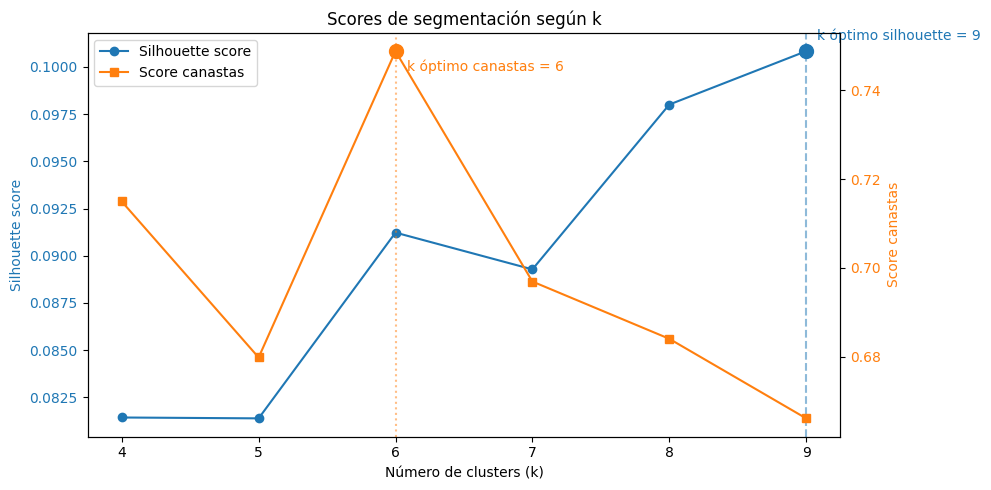

In [182]:
graficar_resultado(resultados_segmentacion)

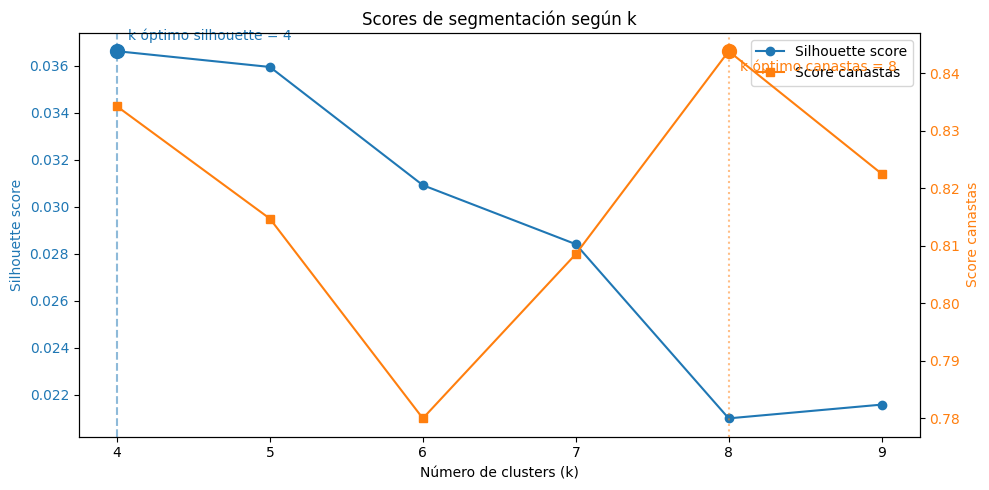

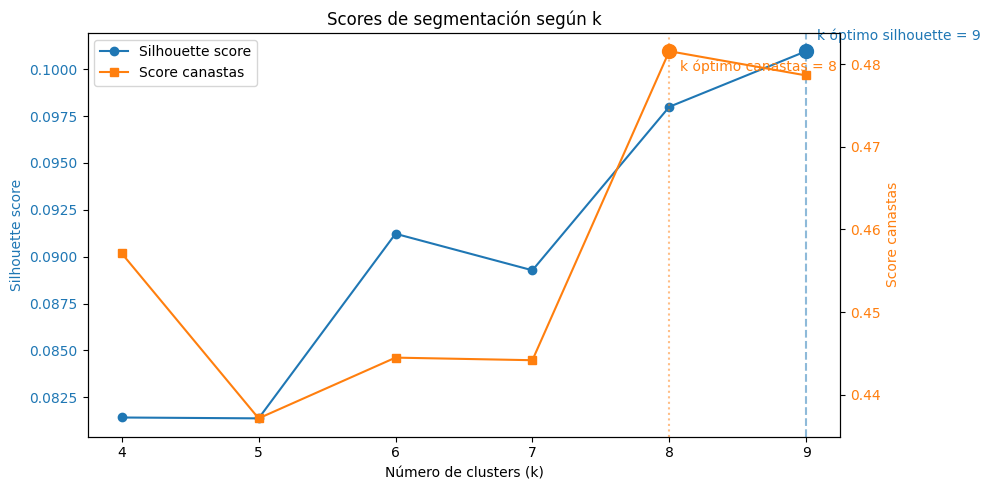

In [162]:
k_elegido = 8
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

In [ ]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

In [ ]:
tabla_cluster_negocio(segmentacion_clientes)

In [163]:
obtener_canasta(
        1,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,Cod SKU,conteo_clientes,porcentaje_clientes_cluster
0,3071,2773,0.691694
1,3239,2735,0.682215
2,3456,2733,0.681716
3,3313,2381,0.593914
4,3032,2294,0.572213
5,8508,1962,0.489399
6,1020,1907,0.475680
7,421,1688,0.421053
8,6783,1603,0.399850
9,3109,1352,0.337241


Canasta del cluster: [3071 3239 3456 3313 3032]


array([3071, 3239, 3456, 3313, 3032])

## 3.2 Por Familia

In [143]:
# Iteramos la clusterización
granularidad_sku = "Nombre Familia"
conteo_compra = "binario"                # Binario, porcentaje de ingresos
verbosity = False
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    verbosity,
)

In [144]:
ks_clustering = range(4, 10)
resultados_segmentacion = evaluar_segmentaciones(
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    umbral=umbral,
    verbosity=verbosity,
)

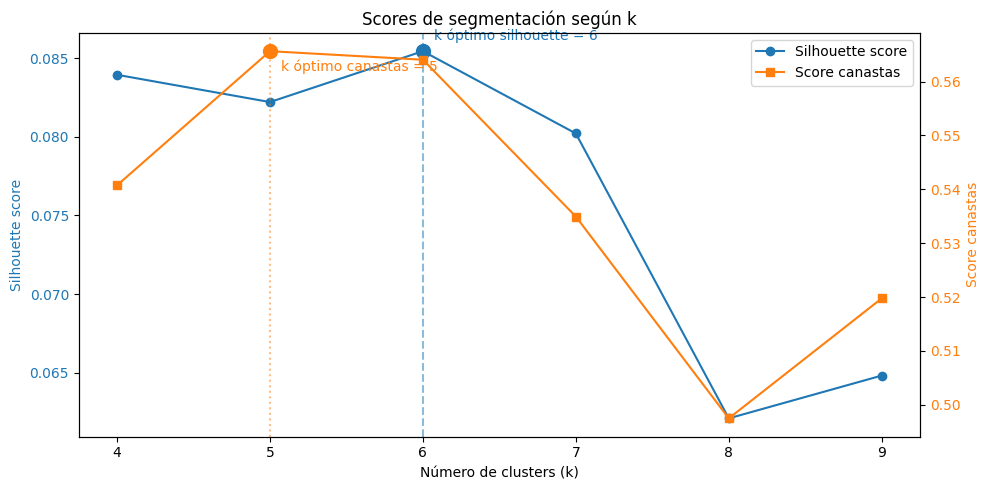

In [145]:
graficar_resultado(resultados_segmentacion)

In [146]:
k_elegido = 7
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

In [147]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster predominante (%)
DesTipoNeg,,,,,,,,
AL - ALMACÉN,13.4,30.7,14.1,12.3,5.7,13.3,10.4,Cluster 2 (30.7%)
CA - CARNICERÍA,13.2,16.6,6.0,3.2,37.9,14.9,8.1,Cluster 5 (37.9%)
FI - FIAMBRERÍA,23.8,16.9,11.2,6.2,4.4,32.5,5.0,Cluster 6 (32.5%)
FS - FUENTEDE SODA,0.0,100.0,0.0,0.0,0.0,0.0,0.0,Cluster 2 (100.0%)
MA - MAYORISTA,0.0,0.0,0.0,0.0,0.0,100.0,0.0,Cluster 6 (100.0%)
MK - MINIMARKET,7.0,65.3,10.7,2.8,3.3,7.5,3.5,Cluster 2 (65.3%)
PA - PANADERÍA,32.9,24.5,6.4,5.7,1.5,25.2,3.7,Cluster 1 (32.9%)
PZ - PIZZERIA,0.0,0.0,0.0,0.0,0.0,0.0,100.0,Cluster 7 (100.0%)
SL - SUPERMERCADO LOCAL,1.9,93.2,1.0,0.0,0.0,1.9,1.9,Cluster 2 (93.2%)


In [148]:
tabla_cluster_negocio(segmentacion_clientes)

DesTipoNeg,AL - ALMACÉN,CA - CARNICERÍA,FI - FIAMBRERÍA,FS - FUENTEDE SODA,MA - MAYORISTA,MK - MINIMARKET,PA - PANADERÍA,PZ - PIZZERIA,SL - SUPERMERCADO LOCAL,Sin TipoNeg,Tipo negocio principal (%)
Cluster 1,70.7,2.0,0.7,0.0,0.0,1.4,13.9,0.0,0.1,11.2,AL - ALMACÉN (70.7%)
Cluster 2,81.3,1.3,0.2,0.0,0.0,6.8,5.2,0.0,1.7,3.5,AL - ALMACÉN (81.3%)
Cluster 3,85.6,1.1,0.4,0.0,0.0,2.5,3.1,0.0,0.0,7.3,AL - ALMACÉN (85.6%)
Cluster 4,85.0,0.6,0.2,0.0,0.0,0.8,3.2,0.0,0.0,10.2,AL - ALMACÉN (85.0%)
Cluster 5,67.3,12.9,0.3,0.0,0.0,1.5,1.4,0.0,0.0,16.6,AL - ALMACÉN (67.3%)
Cluster 6,72.1,2.3,0.9,0.0,0.0,1.6,11.0,0.0,0.1,11.9,AL - ALMACÉN (72.1%)
Cluster 7,84.1,1.9,0.2,0.0,0.0,1.1,2.4,0.0,0.1,10.1,AL - ALMACÉN (84.1%)


In [149]:
obtener_canasta(
        1,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,Nombre Familia,conteo_clientes,porcentaje_clientes_cluster
0,LACTEOS,4909,0.852701
1,PATE,4789,0.831857
2,MORTADELAS,4723,0.820393
3,QUESOS,4573,0.794337
4,SALAMES,4416,0.767066
5,VIENESAS,3986,0.692375
6,JAMON G2,3659,0.635574
7,JAMON G1,3355,0.582769
8,SNACKS,2812,0.488449
9,ARROLLADOS,2173,0.377454


Canasta del cluster: <StringArray>
[   'LACTEOS',       'PATE', 'MORTADELAS',     'QUESOS',    'SALAMES',
   'VIENESAS',   'JAMON G2',   'JAMON G1']
Length: 8, dtype: str


<StringArray>
[   'LACTEOS',       'PATE', 'MORTADELAS',     'QUESOS',    'SALAMES',
   'VIENESAS',   'JAMON G2',   'JAMON G1']
Length: 8, dtype: str

## 3.3 Por Familia - marca

In [150]:
# Iteramos la clusterización
granularidad_sku = "familia_marca"
conteo_compra = "binario"                # Binario, porcentaje de ingresos
verbosity = False
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    verbosity,
)

In [151]:
ks_clustering = range(4, 10)
resultados_segmentacion = evaluar_segmentaciones(
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    umbral=umbral,
    verbosity=verbosity,
)

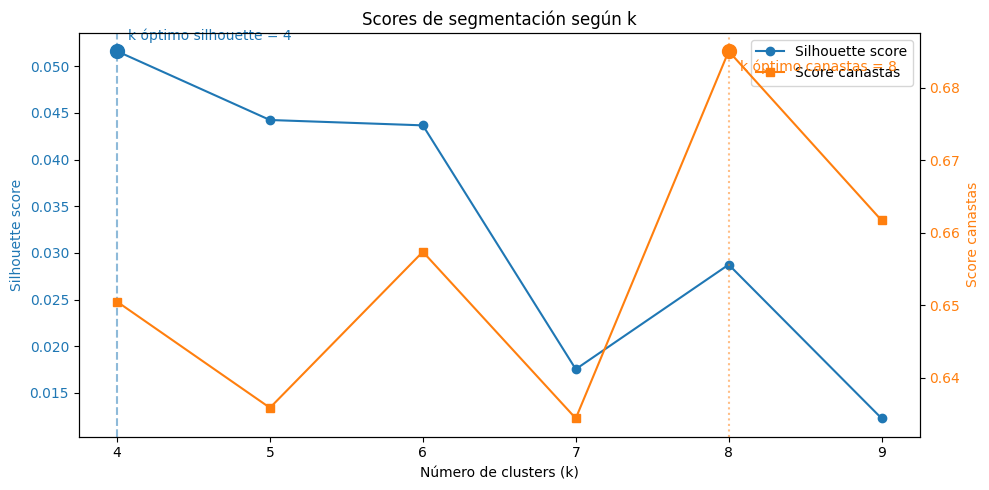

In [152]:
graficar_resultado(resultados_segmentacion)

In [153]:
k_elegido = 7
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

In [154]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster predominante (%)
DesTipoNeg,,,,,,,,
AL - ALMACÉN,12.8,13.3,17.7,14.6,11.4,19.9,10.2,Cluster 6 (19.9%)
CA - CARNICERÍA,11.3,8.1,10.1,16.3,9.1,6.7,38.4,Cluster 7 (38.4%)
FI - FIAMBRERÍA,30.6,14.4,17.5,12.5,10.0,5.0,10.0,Cluster 1 (30.6%)
FS - FUENTEDE SODA,0.0,0.0,0.0,0.0,0.0,100.0,0.0,Cluster 6 (100.0%)
MA - MAYORISTA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
MK - MINIMARKET,12.4,2.9,30.3,6.5,8.5,36.0,3.4,Cluster 6 (36.0%)
PA - PANADERÍA,28.0,20.3,12.2,6.6,17.5,12.0,3.4,Cluster 1 (28.0%)
PZ - PIZZERIA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
SL - SUPERMERCADO LOCAL,1.9,0.5,18.8,0.0,2.4,75.8,0.5,Cluster 6 (75.8%)


In [155]:
tabla_cluster_negocio(segmentacion_clientes)

DesTipoNeg,AL - ALMACÉN,CA - CARNICERÍA,FI - FIAMBRERÍA,FS - FUENTEDE SODA,MA - MAYORISTA,MK - MINIMARKET,PA - PANADERÍA,PZ - PIZZERIA,SL - SUPERMERCADO LOCAL,Sin TipoNeg,Tipo negocio principal (%)
Cluster 1,72.4,1.8,0.9,0.0,0.0,2.8,12.7,0.0,0.1,9.2,AL - ALMACÉN (72.4%)
Cluster 2,77.6,1.4,0.4,0.0,0.0,0.7,9.5,0.0,0.0,10.4,AL - ALMACÉN (77.6%)
Cluster 3,82.0,1.4,0.4,0.0,0.0,5.5,4.5,0.0,0.6,5.6,AL - ALMACÉN (82.0%)
Cluster 4,80.3,2.6,0.4,0.0,0.0,1.4,2.9,0.0,0.0,12.4,AL - ALMACÉN (80.3%)
Cluster 5,78.6,1.8,0.4,0.0,0.0,2.3,9.7,0.0,0.1,7.1,AL - ALMACÉN (78.6%)
Cluster 6,83.0,0.8,0.1,0.0,0.0,5.9,4.1,0.0,2.2,3.9,AL - ALMACÉN (83.0%)
Cluster 7,73.4,8.0,0.4,0.0,0.0,1.0,1.9,0.0,0.0,15.4,AL - ALMACÉN (73.4%)


In [156]:
obtener_canasta(
        1,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,familia_marca,conteo_clientes,porcentaje_clientes_cluster
0,SALAMESLA PREFERIDA,4499,0.840149
1,PATELA PREFERIDA,4382,0.818301
2,JAMON G1LA PREFERIDA,4174,0.779458
3,JAMON G2LA PREFERIDA,3763,0.702708
4,MORTADELASLA PREFERIDA,3642,0.680112
5,VIENESASSAN JORGE,3234,0.603922
6,PATESAN JORGE,3103,0.579458
7,LACTEOSLos Nogales,2914,0.544164
8,SNACKSLA PREFERIDA,2827,0.527918
9,QUESOSLos Nogales,2758,0.515033


Canasta del cluster: <StringArray>
[   'SALAMESLA PREFERIDA',       'PATELA PREFERIDA',   'JAMON G1LA PREFERIDA',
   'JAMON G2LA PREFERIDA', 'MORTADELASLA PREFERIDA',      'VIENESASSAN JORGE',
          'PATESAN JORGE',     'LACTEOSLos Nogales',     'SNACKSLA PREFERIDA',
      'QUESOSLos Nogales']
Length: 10, dtype: str


<StringArray>
[   'SALAMESLA PREFERIDA',       'PATELA PREFERIDA',   'JAMON G1LA PREFERIDA',
   'JAMON G2LA PREFERIDA', 'MORTADELASLA PREFERIDA',      'VIENESASSAN JORGE',
          'PATESAN JORGE',     'LACTEOSLos Nogales',     'SNACKSLA PREFERIDA',
      'QUESOSLos Nogales']
Length: 10, dtype: str